In [3]:
import pandas as pd
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt

# Make plots larger
plt.rcParams["figure.figsize"] = (10,6)
plt.rcParams["figure.dpi"] = 120

print("Libraries imported successfully!")

Libraries imported successfully!


In [4]:
# Load the exported Gephi metrics
nodes = pd.read_csv("amazon_nodes_metrics.csv")

print("Dataset Loaded Successfully!\n")

print("Number of rows :", len(nodes))
print("Number of columns :", len(nodes.columns))

Dataset Loaded Successfully!

Number of rows : 90828
Number of columns : 13


C:\Users\leena\AppData\Local\Temp\ipykernel_22136\4092235112.py:2: DtypeWarning: Columns (1,2,4) have mixed types. Specify dtype option on import or set low_memory=False.
  nodes = pd.read_csv("amazon_nodes_metrics.csv")


In [5]:
# Show all column names

print("Columns in the dataset:\n")

for col in nodes.columns:
    print(col)

Columns in the dataset:

Id
Label
category
price (usd)
recommended product ids
indegree
outdegree
Degree
pageranks
componentnumber
strongcompnum
modularity_class
clustering


In [6]:
nodes.head()

,Id,Label,category,price (usd),recommended product ids,indegree,outdegree,Degree,pageranks,componentnumber,strongcompnum,modularity_class,clustering
0,0078764343,NaN,Games,37.98,"B000TI836G,B003Q53VZC,B00EFFW0HC,B003VWGBC0,B0...",1,24,25,0.000006,0,0,1645,0.478261
1,043933702X,NaN,Games,23.50,NaN,0,0,0,0.000006,1,0,0,0.000000
2,0439339987,NaN,Games,8.95,"B000314VVU,B000PXUOTE,B00004TJCM,B0006U22XC,B0...",2,13,15,0.000006,0,0,19277,0.141026
3,0439342260,NaN,Games,NaN,NaN,0,0,0,0.000006,2,0,1,0.000000
4,0439339960,NaN,Games,NaN,NaN,0,0,0,0.000006,3,0,2,0.000000


In [7]:
nodes.isnull().sum()

Id                             0
Label                      88563
category                   39875
price (usd)                46923
recommended product ids    61863
indegree                       0
outdegree                      0
Degree                         0
pageranks                      0
componentnumber                0
strongcompnum                  0
modularity_class               0
clustering                     0
dtype: int64

In [8]:
# Products that actually belong to the original dataset

original_products = nodes[nodes["category"].notna()]

print("Original products :", len(original_products))

# Auto-created recommendation-only nodes

extra_nodes = nodes[nodes["category"].isna()]

print("Extra nodes :", len(extra_nodes))

Original products : 50953
Extra nodes : 39875


In [9]:
clean = nodes[nodes["category"].notna()].copy()

print("Rows after cleaning:", len(clean))

Rows after cleaning: 50953


In [10]:
print("="*50)
print("NETWORK STATISTICS")
print("="*50)

print(f"Number of Products : {len(clean)}")

print(f"Average Degree     : {clean['Degree'].mean():.3f}")
print(f"Average In-Degree  : {clean['indegree'].mean():.3f}")
print(f"Average Out-Degree : {clean['outdegree'].mean():.3f}")

print(f"Average PageRank   : {clean['pageranks'].mean():.8f}")

print(f"Average Clustering : {clean['clustering'].mean():.4f}")

print(f"Communities        : {clean['modularity_class'].nunique()}")

NETWORK STATISTICS
Number of Products : 50953
Average Degree     : 50.463
Average In-Degree  : 22.865
Average Out-Degree : 27.598
Average PageRank   : 0.00001422
Average Clustering : 0.1736
Communities        : 19401


In [11]:
print("="*50)
print("DEGREE STATISTICS")
print("="*50)

clean["Degree"].describe()

DEGREE STATISTICS


count    50953.000000
mean        50.462917
std         85.510494
min          0.000000
25%          0.000000
50%          9.000000
75%         73.000000
max       1544.000000
Name: Degree, dtype: float64

In [ ]:
import pandas as pd
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt

# Make plots larger
plt.rcParams["figure.figsize"] = (10,6)
plt.rcParams["figure.dpi"] = 120

print("Libraries imported successfully!")

Libraries imported successfully!


In [ ]:
# Load the exported Gephi metrics
nodes = pd.read_csv("amazon_nodes_metrics.csv")

print("Dataset Loaded Successfully!\n")

print("Number of rows :", len(nodes))
print("Number of columns :", len(nodes.columns))

Dataset Loaded Successfully!

Number of rows : 90828
Number of columns : 13


C:\Users\leena\AppData\Local\Temp\ipykernel_22136\4092235112.py:2: DtypeWarning: Columns (1,2,4) have mixed types. Specify dtype option on import or set low_memory=False.
  nodes = pd.read_csv("amazon_nodes_metrics.csv")


In [ ]:
# Show all column names

print("Columns in the dataset:\n")

for col in nodes.columns:
    print(col)

Columns in the dataset:

Id
Label
category
price (usd)
recommended product ids
indegree
outdegree
Degree
pageranks
componentnumber
strongcompnum
modularity_class
clustering


In [ ]:
nodes.head()

,Id,Label,category,price (usd),recommended product ids,indegree,outdegree,Degree,pageranks,componentnumber,strongcompnum,modularity_class,clustering
0,0078764343,NaN,Games,37.98,"B000TI836G,B003Q53VZC,B00EFFW0HC,B003VWGBC0,B0...",1,24,25,0.000006,0,0,1645,0.478261
1,043933702X,NaN,Games,23.50,NaN,0,0,0,0.000006,1,0,0,0.000000
2,0439339987,NaN,Games,8.95,"B000314VVU,B000PXUOTE,B00004TJCM,B0006U22XC,B0...",2,13,15,0.000006,0,0,19277,0.141026
3,0439342260,NaN,Games,NaN,NaN,0,0,0,0.000006,2,0,1,0.000000
4,0439339960,NaN,Games,NaN,NaN,0,0,0,0.000006,3,0,2,0.000000


In [ ]:
nodes.isnull().sum()

Id                             0
Label                      88563
category                   39875
price (usd)                46923
recommended product ids    61863
indegree                       0
outdegree                      0
Degree                         0
pageranks                      0
componentnumber                0
strongcompnum                  0
modularity_class               0
clustering                     0
dtype: int64

In [12]:
top_pr = clean.sort_values("pageranks", ascending=False)

top_pr[[
    "Id",
    "category",
    "Degree",
    "pageranks"
]].head(10)

,Id,category,Degree,pageranks
21674,B000TLU67W,Consoles,1544,0.000694
5131,B00004YRQA,Accessories,1493,0.000649
5141,B00004YRQ9,Games,1310,0.000580
27309,B001MW91IW,Memory Cards,1227,0.000551
35583,B0045L3SNQ,Accessories,916,0.000424
10408,B0000C7GHG,Consoles,910,0.000414
34903,B003ZSP0WW,Computers & Accessories,1214,0.000369
2109,B00002STXQ,Games,754,0.000367
23597,B0013KW1B2,PlayStation 2,790,0.000362
30373,B002KJ02ZC,Accessories,740,0.000341


In [13]:
community_sizes = clean.groupby("modularity_class").size()

community_sizes = community_sizes.sort_values(ascending=False)

community_sizes.head(10)

modularity_class
118      4322
15626    3924
1369     3884
1645     3787
6043     3067
14855    2774
19370    2416
2102     2180
2068     1584
15322    1435
dtype: int64

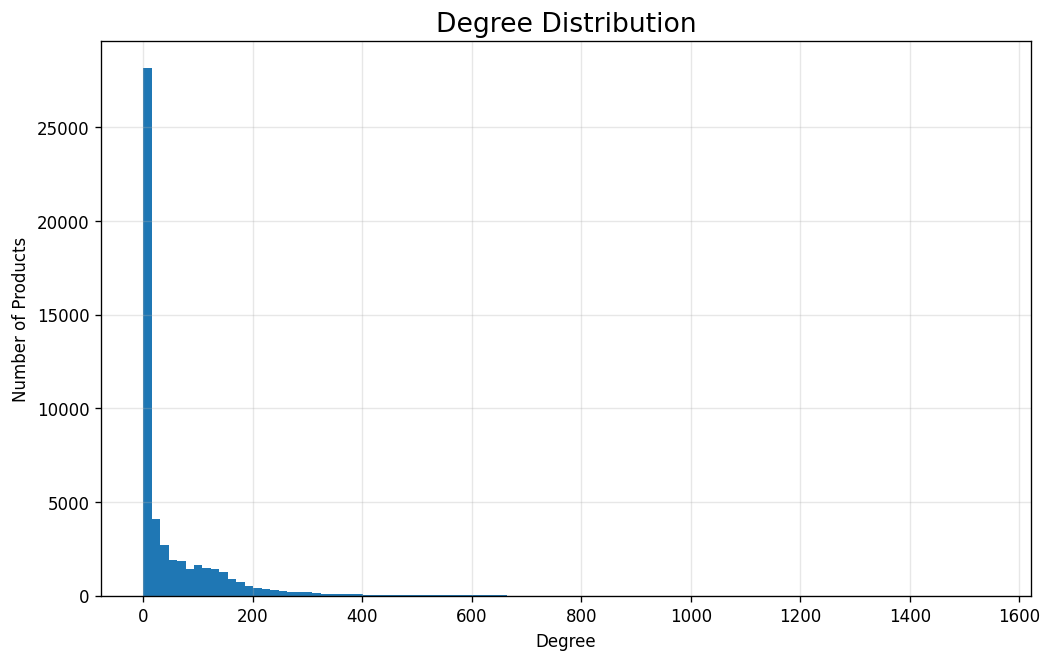

In [14]:
plt.figure(figsize=(10,6))

plt.hist(clean["Degree"], bins=100)

plt.title("Degree Distribution", fontsize=16)
plt.xlabel("Degree")
plt.ylabel("Number of Products")

plt.grid(alpha=0.3)

plt.show()

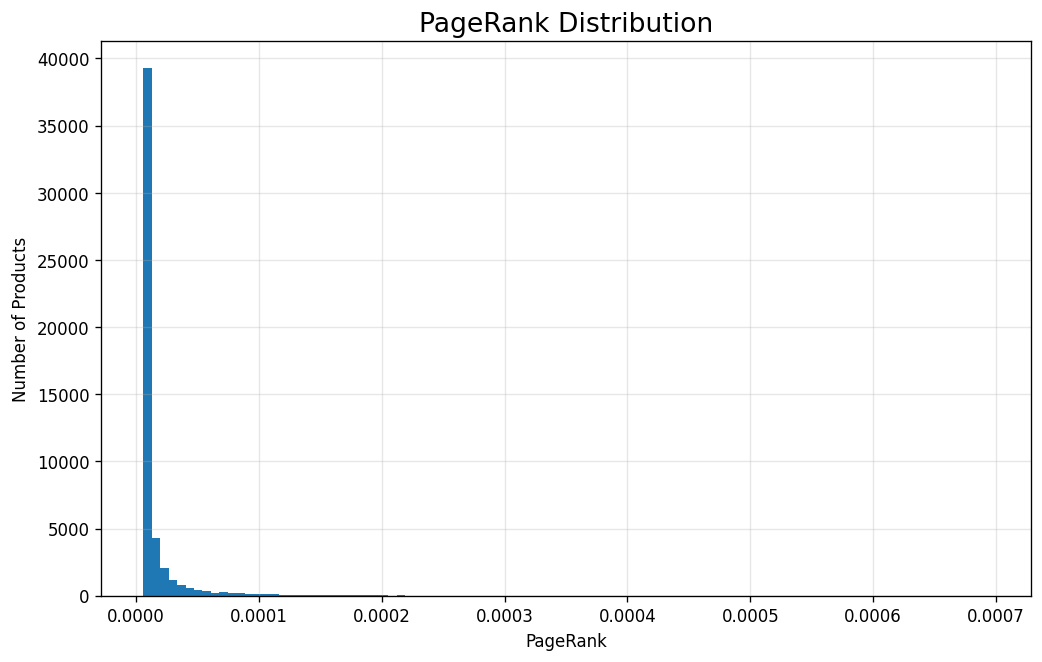

In [15]:
plt.figure(figsize=(10,6))

plt.hist(clean["pageranks"], bins=100)

plt.title("PageRank Distribution", fontsize=16)
plt.xlabel("PageRank")
plt.ylabel("Number of Products")

plt.grid(alpha=0.3)

plt.show()

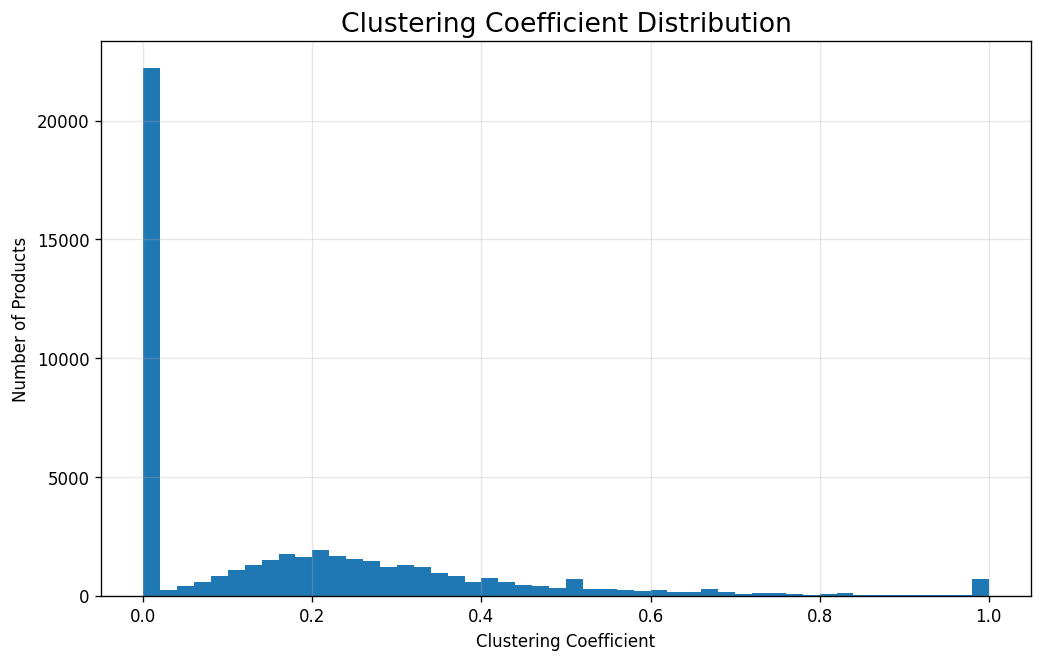

In [16]:
plt.figure(figsize=(10,6))

plt.hist(clean["clustering"], bins=50)

plt.title("Clustering Coefficient Distribution", fontsize=16)
plt.xlabel("Clustering Coefficient")
plt.ylabel("Number of Products")

plt.grid(alpha=0.3)

plt.show()

In [17]:
summary = pd.DataFrame({
    "Metric": [
        "Number of Products",
        "Average Degree",
        "Average In-Degree",
        "Average Out-Degree",
        "Average PageRank",
        "Average Clustering Coefficient",
        "Number of Communities"
    ],
    "Value": [
        len(clean),
        clean["Degree"].mean(),
        clean["indegree"].mean(),
        clean["outdegree"].mean(),
        clean["pageranks"].mean(),
        clean["clustering"].mean(),
        clean["modularity_class"].nunique()
    ]
})

summary

,Metric,Value
0,Number of Products,50953.000000
1,Average Degree,50.462917
2,Average In-Degree,22.864503
3,Average Out-Degree,27.598414
4,Average PageRank,0.000014
5,Average Clustering Coefficient,0.173628
6,Number of Communities,19401.000000


In [18]:
category_count = clean["category"].value_counts()

category_count.head(15)

category
Games                 22427
Kids & Family          5379
Accessories            3247
Casual Games           2161
PC Game Downloads      2129
Cases & Protectors     1692
Skins                  1539
Accessory Kits         1182
PlayStation 2          1089
Gamepads                745
Controllers             656
Consoles                541
Cables                  472
Chargers                467
Video Games             416
Name: count, dtype: int64

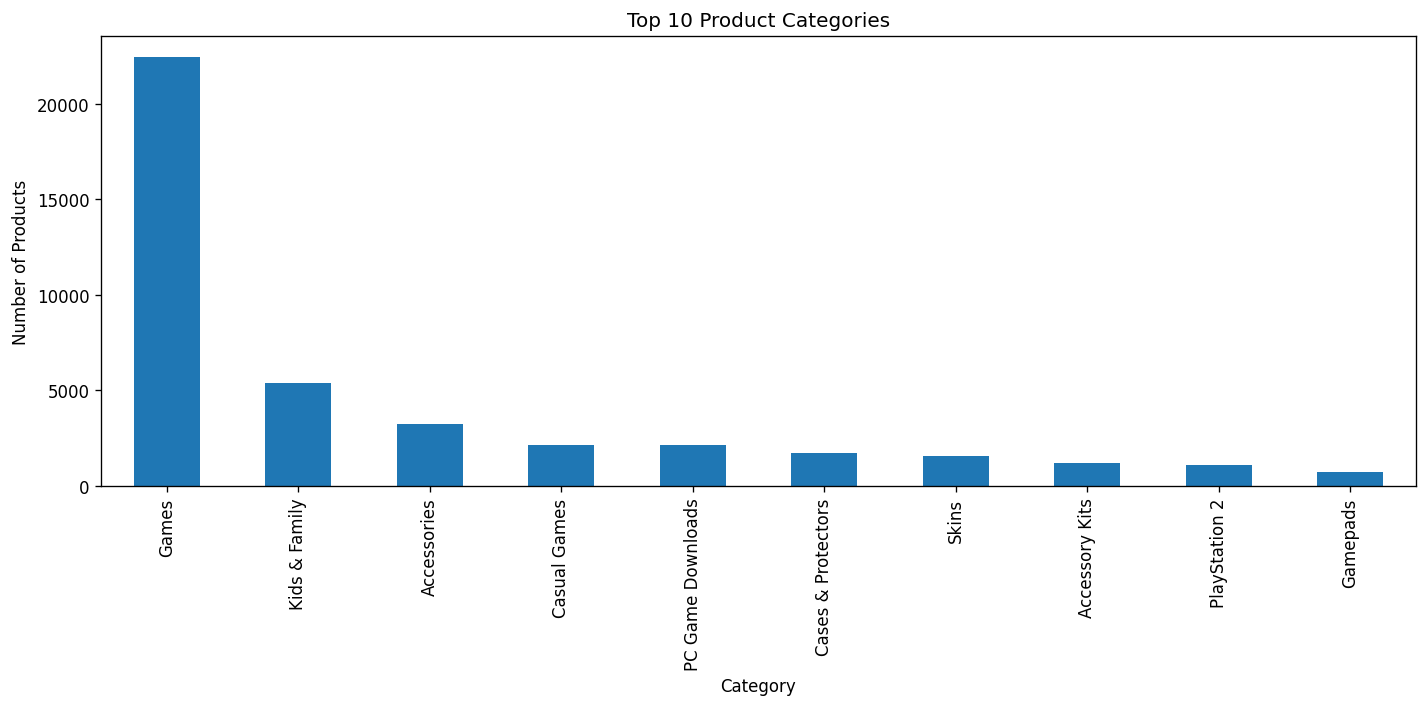

In [19]:
plt.figure(figsize=(12,6))

category_count.head(10).plot(kind="bar")

plt.title("Top 10 Product Categories")
plt.xlabel("Category")
plt.ylabel("Number of Products")

plt.tight_layout()
plt.show()

In [20]:
top_degree = clean.sort_values("Degree", ascending=False)

top_degree[
    ["Id", "category", "Degree", "pageranks"]
].head(10)

,Id,category,Degree,pageranks
21674,B000TLU67W,Consoles,1544,0.000694
5131,B00004YRQA,Accessories,1493,0.000649
5141,B00004YRQ9,Games,1310,0.000580
27309,B001MW91IW,Memory Cards,1227,0.000551
48753,B00FQPQGSY,PC Game Downloads,1225,0.000245
34903,B003ZSP0WW,Computers & Accessories,1214,0.000369
43804,B00917DBUE,PC Game Downloads,1193,0.000245
44258,B009K6YJTS,PC Game Downloads,993,0.000186
42151,B007VFHGZ4,PC Game Downloads,984,0.000196
16983,B000ERVMI8,Games,936,0.000323


In [21]:
top_cluster = clean.sort_values("clustering", ascending=False)

top_cluster[
    ["Id", "category", "clustering"]
].head(10)

,Id,category,clustering
50936,B00L5JULQI,Casual Games,1.0
11655,B0002BQNDA,Games,1.0
2180,B00002STWX,Games,1.0
8198,B00006IINZ,Games,1.0
8222,B00006IJMU,Games,1.0
50758,B00JSADAB4,Casual Games,1.0
50755,B00JS6VYQQ,Casual Games,1.0
35070,B00414GMAI,Video Games,1.0
10141,B0000A2PMH,PC,1.0
38323,B0050SVLZK,Games,1.0


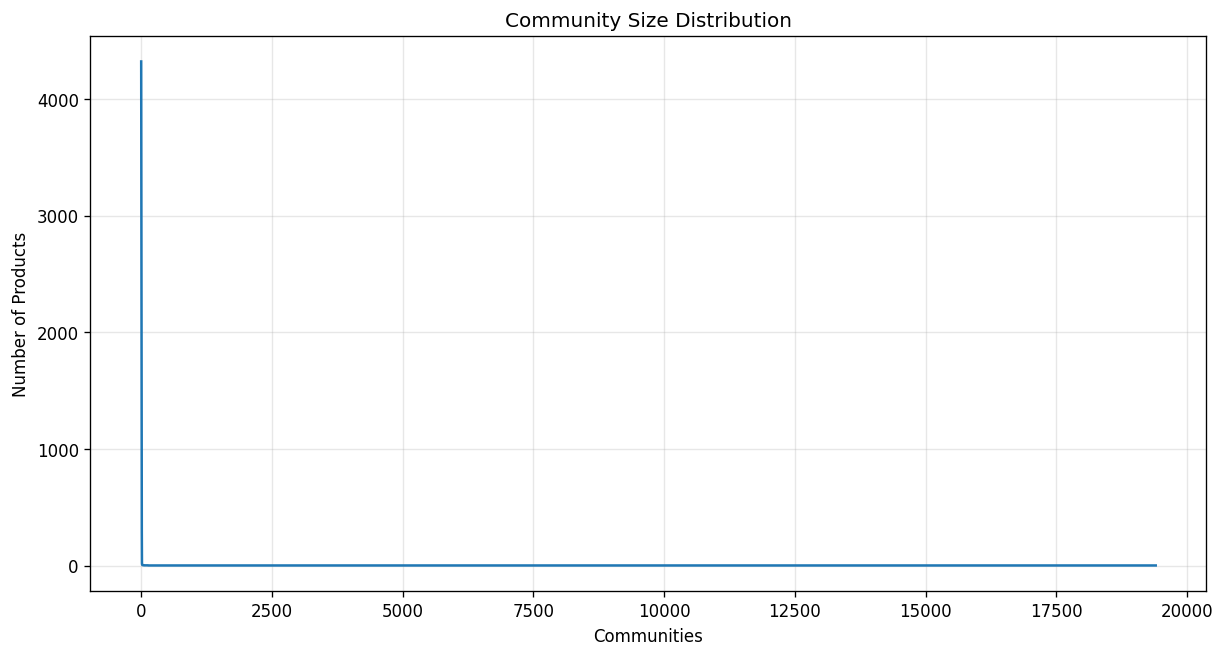

In [22]:
community_sizes = clean.groupby("modularity_class").size()

community_sizes = community_sizes.sort_values(ascending=False)

plt.figure(figsize=(12,6))

plt.plot(range(1, len(community_sizes)+1),
         community_sizes.values)

plt.title("Community Size Distribution")
plt.xlabel("Communities")
plt.ylabel("Number of Products")

plt.grid(alpha=0.3)

plt.show()

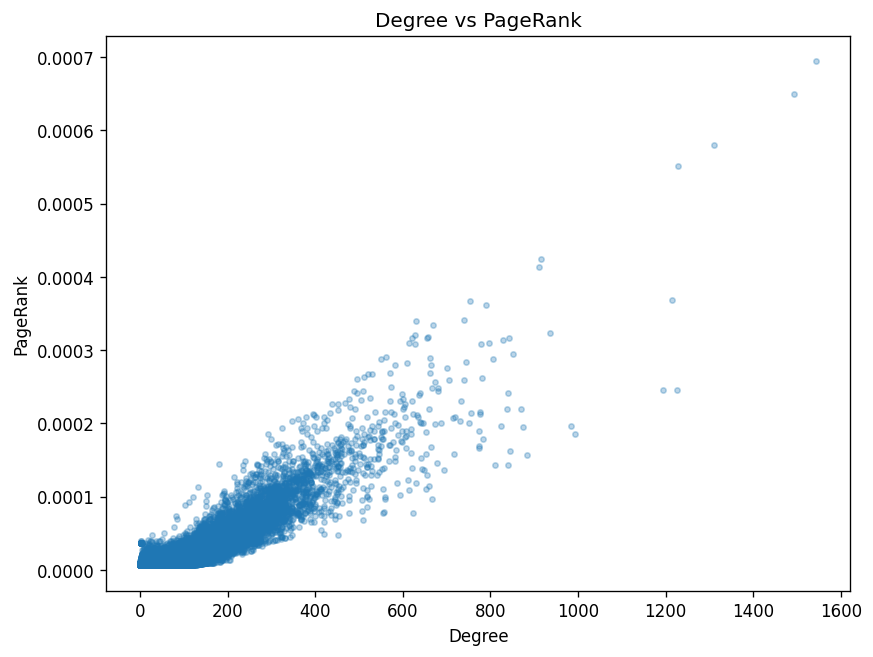

In [23]:
plt.figure(figsize=(8,6))

plt.scatter(
    clean["Degree"],
    clean["pageranks"],
    alpha=0.3,
    s=10
)

plt.xlabel("Degree")
plt.ylabel("PageRank")
plt.title("Degree vs PageRank")

plt.show()

In [24]:
plt.savefig("degree_distribution.png", dpi=300, bbox_inches="tight")

<Figure size 1200x720 with 0 Axes>

In [25]:
summary.to_csv("summary_statistics.csv", index=False)

top_pr.to_csv("top_pagerank_products.csv", index=False)

top_degree.to_csv("top_degree_products.csv", index=False)

top_cluster.to_csv("top_clustering_products.csv", index=False)

community_sizes.to_csv("community_sizes.csv")